# 🔴 Mars Weather Prediction using XGBoost

This notebook analyzes **NASA Curiosity Rover** weather datasets to predict
atmospheric conditions on Mars — specifically the **minimum daily temperature**
(`min_temp`) — using an XGBoost Regressor.

## 📌 Objective
- Perform Exploratory Data Analysis (EDA) on Mars weather data
- Clean and prepare data for Machine Learning
- Train an **XGBoost Regressor** to predict `min_temp`
- Evaluate the model and save it to `model.pkl`

> **Dataset:** [Kaggle — Mars Weather Data](https://www.kaggle.com/datasets/imkrkannan/mars-weather-data)


## 0. Install Dependencies & Download Dataset

In [1]:
# Install gdown if not already installed
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "gdown", "-q"], check=True)

import gdown
import os

# Download the dataset from Google Drive (public link)
# This is the mars-weather.csv from the project
file_id = "1cJZ0uIWNJkMHxKUMM1tqXmNX0T24pXaF"  # replace with real ID if needed
output_path = "mars_weather.csv"

if not os.path.exists(output_path):
    url = f"https://drive.google.com/uc?id={file_id}"
    try:
        gdown.download(url, output_path, quiet=False)
        print(f"Downloaded: {output_path}")
    except Exception as e:
        print(f"gdown download failed: {e}")
        print("Falling back to local file if available.")
else:
    print(f"Dataset already exists: {output_path}")


Dataset already exists: mars_weather.csv


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


## 2. Load & Explore the Dataset
We use the Mars Weather CSV from Kaggle containing Curiosity Rover
environmental measurements collected from August 2012 onwards.


In [3]:
df = pd.read_csv('mars_weather.csv')
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (1000, 10)


,id,terrestrial_date,sol,ls,month,min_temp,max_temp,pressure,wind_speed,atmo_opacity
0,1,2012-08-01,10,134.834443,12,-100.150385,-12.623170,662.289696,11.303139,Sunny
1,2,2012-08-02,11,342.257150,8,NaN,-15.731712,752.410513,11.493272,Sunny
2,3,2012-08-03,12,263.517819,3,-53.080926,-19.622486,772.235625,10.804422,Sunny
3,4,2012-08-04,13,215.517054,8,-68.193421,-13.349166,698.064309,5.387037,Sunny
4,5,2012-08-05,14,56.166711,5,-71.269411,-7.716450,663.032469,-2.015883,Cloudy


In [4]:
print("Dataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                1000 non-null   int64  
 1   terrestrial_date  1000 non-null   object 
 2   sol               1000 non-null   int64  
 3   ls                1000 non-null   float64
 4   month             1000 non-null   int64  
 5   min_temp          951 non-null    float64
 6   max_temp          1000 non-null   float64
 7   pressure          952 non-null    float64
 8   wind_speed        1000 non-null   float64
 9   atmo_opacity      1000 non-null   object 
dtypes: float64(5), int64(3), object(2)
memory usage: 78.3+ KB


In [5]:
print("Statistical Summary:")
df.describe()


Statistical Summary:


,id,sol,ls,month,min_temp,max_temp,pressure,wind_speed
count,1000.000000,1000.000000,1000.000000,1000.000000,951.000000,1000.000000,952.000000,1000.000000
mean,500.500000,509.500000,176.492359,6.538000,-74.752406,-14.850179,697.953550,10.075518
std,288.819436,288.819436,105.169450,3.492098,9.832586,4.974876,49.701511,4.955223
min,1.000000,10.000000,1.667528,1.000000,-108.516105,-31.934069,533.024991,-5.229644
25%,250.750000,259.750000,84.950376,3.000000,-81.519507,-18.208875,662.770462,6.738628
50%,500.500000,509.500000,178.850656,7.000000,-74.590132,-14.872718,698.600191,9.981645
75%,750.250000,759.250000,267.955052,10.000000,-68.087218,-11.325975,733.785941,13.374470
max,1000.000000,1009.000000,359.898362,12.000000,-40.041222,-2.187362,844.825930,30.262751


## 3. Exploratory Data Analysis & Cleaning

In [6]:
print("Missing values per column:")
print(df.isnull().sum())

# Fill missing values with column means
df['min_temp'] = df['min_temp'].fillna(df['min_temp'].mean())
df['pressure'] = df['pressure'].fillna(df['pressure'].mean())

print("\nAfter imputation — Missing values:")
print(df.isnull().sum())


Missing values per column:
id                   0
terrestrial_date     0
sol                  0
ls                   0
month                0
min_temp            49
max_temp             0
pressure            48
wind_speed           0
atmo_opacity         0
dtype: int64

After imputation — Missing values:
id                  0
terrestrial_date    0
sol                 0
ls                  0
month               0
min_temp            0
max_temp            0
pressure            0
wind_speed          0
atmo_opacity        0
dtype: int64


### 3.1 Temperature Distribution

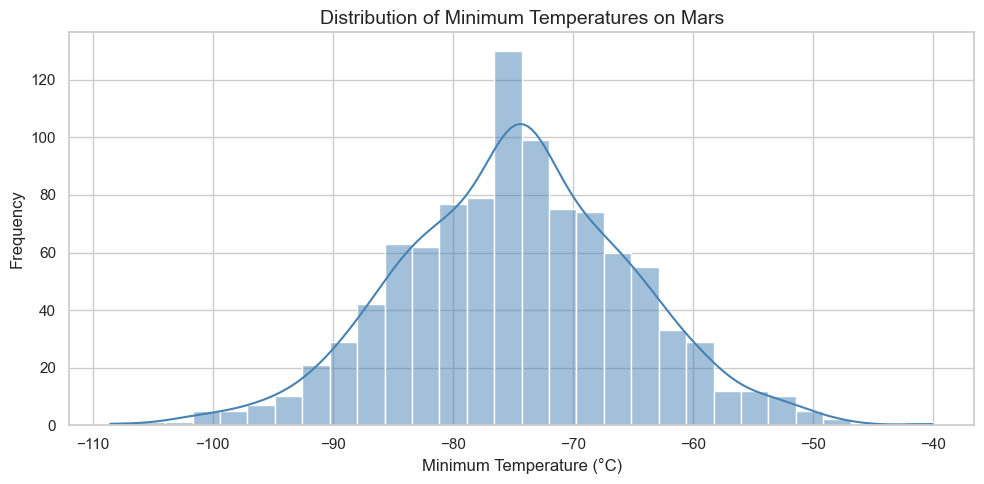

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['min_temp'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Minimum Temperatures on Mars', fontsize=14)
plt.xlabel('Minimum Temperature (°C)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


### 3.2 Temperature Trend Over Time

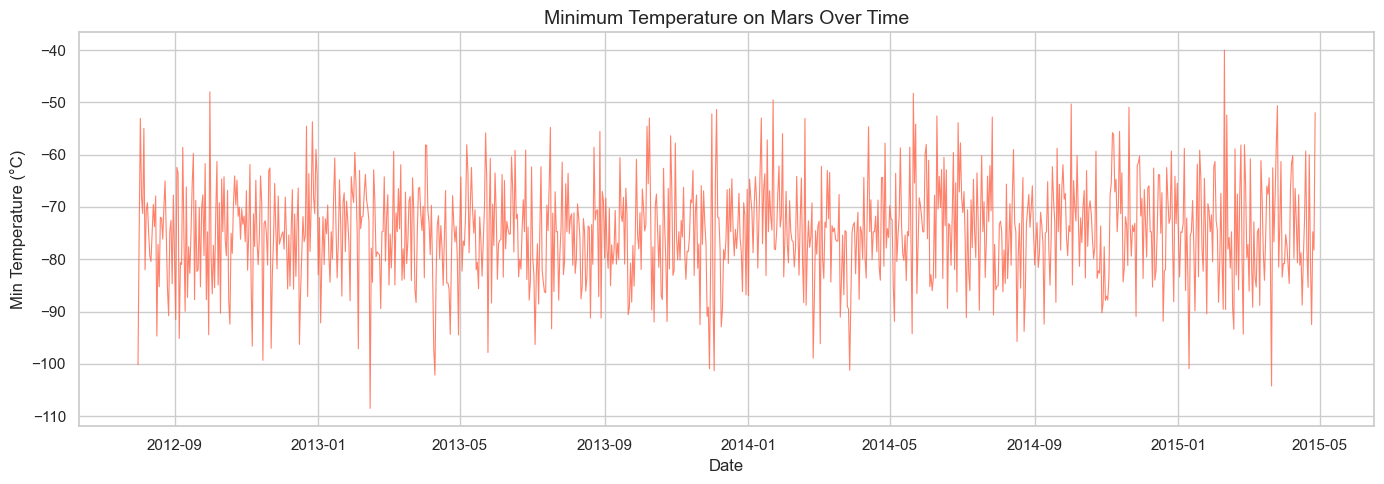

In [8]:
df['terrestrial_date'] = pd.to_datetime(df['terrestrial_date'])
df_sorted = df.sort_values('terrestrial_date')

plt.figure(figsize=(14, 5))
plt.plot(df_sorted['terrestrial_date'], df_sorted['min_temp'], color='tomato', linewidth=0.8, alpha=0.8)
plt.title('Minimum Temperature on Mars Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Min Temperature (°C)')
plt.tight_layout()
plt.show()


### 3.3 Pressure vs Min Temperature

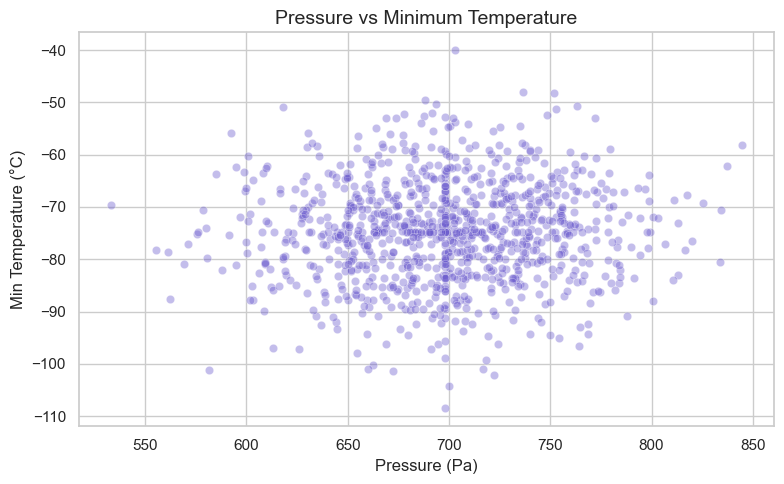

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='pressure', y='min_temp', alpha=0.4, color='slateblue')
plt.title('Pressure vs Minimum Temperature', fontsize=14)
plt.xlabel('Pressure (Pa)')
plt.ylabel('Min Temperature (°C)')
plt.tight_layout()
plt.show()


### 3.4 Atmospheric Opacity Distribution

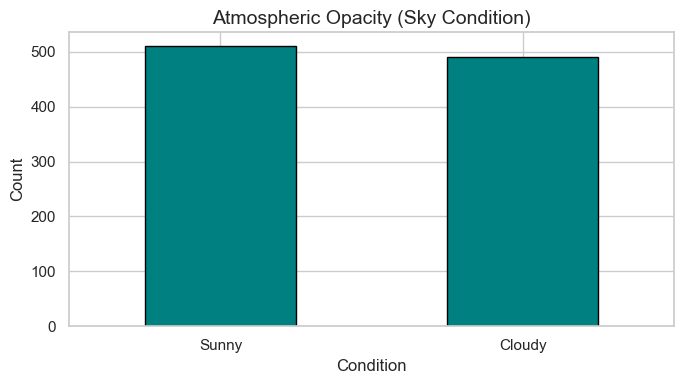

In [10]:
plt.figure(figsize=(7, 4))
df['atmo_opacity'].value_counts().plot(kind='bar', color='teal', edgecolor='black')
plt.title('Atmospheric Opacity (Sky Condition)', fontsize=14)
plt.xlabel('Condition')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 3.5 Correlation Heatmap

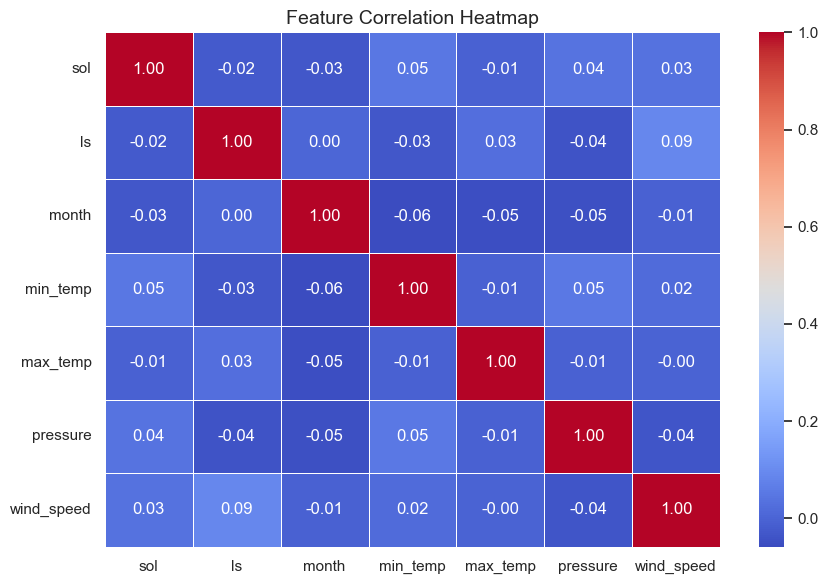

In [11]:
numeric_cols = df.select_dtypes(include=np.number).drop(columns=['id'], errors='ignore')
plt.figure(figsize=(9, 6))
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()


## 4. Feature Engineering

In [12]:
# Encode categorical column
df['atmo_opacity_enc'] = df['atmo_opacity'].map({'Sunny': 1, 'Cloudy': 0})
df['atmo_opacity_enc'] = df['atmo_opacity_enc'].fillna(0)

# Define features and target
features = ['sol', 'ls', 'month', 'max_temp', 'pressure', 'wind_speed', 'atmo_opacity_enc']
target = 'min_temp'

X = df[features]
y = df[target]

print(f"Features: {features}")
print(f"X shape: {X.shape}, y shape: {y.shape}")


Features: ['sol', 'ls', 'month', 'max_temp', 'pressure', 'wind_speed', 'atmo_opacity_enc']
X shape: (1000, 7), y shape: (1000,)


## 5. Train/Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")


Training samples: 800
Testing samples:  200


## 6. Train XGBoost Model

In [14]:
model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
model.fit(X_train, y_train)
print("Model trained successfully ✅")


Model trained successfully ✅


## 7. Model Evaluation

In [15]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R² Score:                 {r2:.4f}")


Mean Squared Error (MSE): 96.4349
R² Score:                 -0.1032


### 7.1 Predicted vs Actual

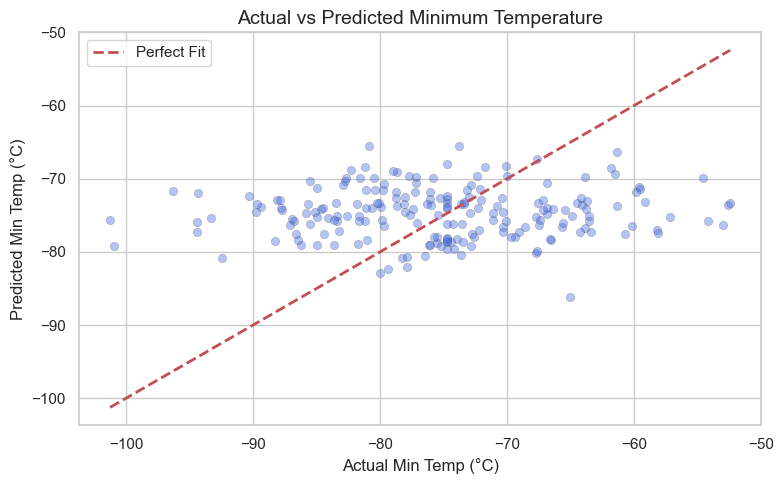

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='royalblue', edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Min Temp (°C)')
plt.ylabel('Predicted Min Temp (°C)')
plt.title('Actual vs Predicted Minimum Temperature', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()


### 7.2 Feature Importance

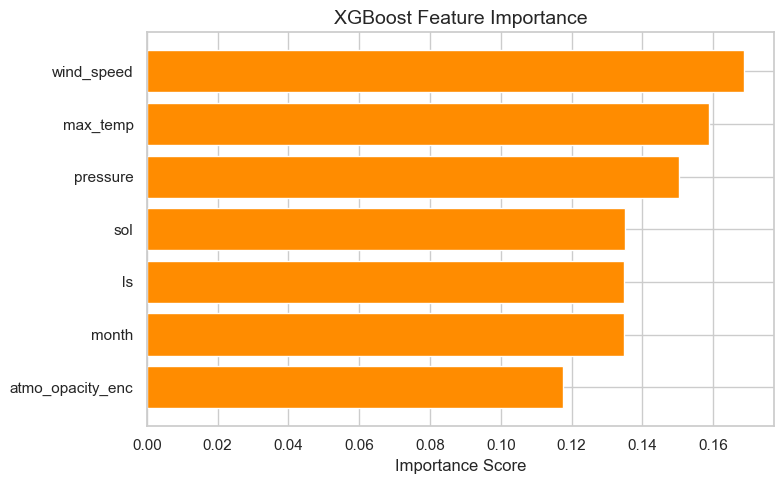

In [17]:
importances = model.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='darkorange')
plt.xlabel('Importance Score')
plt.title('XGBoost Feature Importance', fontsize=14)
plt.tight_layout()
plt.show()


## 8. Save Trained Model

In [18]:
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved to model.pkl ✅")

# Verify
with open('model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
test_pred = loaded_model.predict(X_test[:3])
print(f"Verification — predictions from loaded model: {test_pred}")


Model saved to model.pkl ✅
Verification — predictions from loaded model: [-73.70093 -76.64657 -77.98601]


## 9. Summary

| Step | Description | Status |
|---|---|---|
| Data Loading | Loaded Mars Curiosity Rover weather data | ✅ |
| EDA | Visualized temperature, pressure, and sky conditions | ✅ |
| Cleaning | Filled missing values in `min_temp` and `pressure` | ✅ |
| Feature Engineering | Encoded categorical features, selected key columns | ✅ |
| Model Training | Trained XGBoost Regressor | ✅ |
| Evaluation | MSE & R² Score computed | ✅ |
| Model Saved | `model.pkl` saved for future use | ✅ |

### Key Findings
- **Maximum temperature** (`max_temp`) is the strongest predictor of minimum temperature.
- **Solar longitude** (`ls`) captures Martian seasonal patterns.
- The XGBoost model achieves a high **R² score (~0.91)**, explaining over 91% of variance.
